# Method development: Random Forest Regression
https://www.geeksforgeeks.org/machine-learning/random-forest-regression-in-python/

In [2]:
#%pip install --upgrade pip
#%pip install pandas pyarrow numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [3]:
# Importing clean dataset
df_listings = pd.read_parquet('../data/clean_listings.parquet', engine='auto')
df_rates = pd.read_parquet('../data/clean_past_rates.parquet', engine='auto')
df_all = pd.read_parquet('../data/clean_all_data.parquet', engine='auto')

In [4]:
non_null_count_listings = df_all.notnull().sum().values
nulls = df_all.isna().sum()
types = df_all.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
#print(info_df)

In [5]:
len(df_all.columns)
all_cols = df_all.columns
listings_cols = df_listings.columns
print(len(all_cols), len(listings_cols))
dif = [col for col in all_cols if col not in listings_cols]
print(dif)
print(all_cols)
print(listings_cols)

65 39
['rate_avg_mean', 'rate_avg_median', 'rate_avg_std', 'booked_rate_avg_mean', 'booked_rate_avg_median', 'revpar_mean', 'revpar_std', 'occupancy_rate_mean', 'occupancy_rate_max', 'occupancy_rate_std', 'vacant_days_mean', 'reserved_days_mean', 'revenue_mean', 'revenue_total', 'booking_lead_time_mean', 'length_of_stay_mean', 'min_night_mean', 'n_months', 'peak_rate_avg', 'peak_occupancy', 'peak_revpar', 'offpeak_rate_avg', 'offpeak_occupancy', 'offpeak_revpar', 'peak_rate_premium', 'peak_occupancy_lift']
Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'guests', 'bedrooms', 'beds',
       'baths', 'registration', 'amenities', 'amenities_count', 'instant_book',
       'professional_management', 'min_nights', 'cancellation_policy',
       'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall',
       'rating_accuracy', 'rating_checkin', 'rating_cleanliness',
       'rating_communication', 'rating_location', 

In [6]:
# Selecting cols
cols = [
    # --- original ---
    'room_type', 'photos_count', 'superhost', 'guests', 'bedrooms', 'beds', 'baths',
    'amenities_count', 'cleaning_fee', 'num_reviews', 'rating_overall', 'ttm_revenue',
    'country', 'city',

    # --- new from rates join ---
    'booked_rate_avg_mean',
    'rate_avg_std',
    'peak_rate_premium',
    'occupancy_rate_mean',
    'occupancy_rate_std',
    'peak_occupancy_lift',
    'booking_lead_time_mean',
    'length_of_stay_mean',
    'revpar_mean',
]

df_all_cols = df_all[cols].copy()

In [7]:
# Encoding categorical columns
# TODO: change for One Hot Encoder
label_encoder = LabelEncoder()

for col in df_all_cols.select_dtypes(include=["object"]).columns:
    df_all_cols[col] = label_encoder.fit_transform(df_all_cols[col].astype(str))

print(df_all_cols.isna().sum())
print(len(df_all_cols))
# Not the best approach, but simple solution for testing
df_all_cols = df_all_cols.dropna()
print(len(df_all_cols))

room_type                    0
photos_count                 0
superhost                    0
guests                       0
bedrooms                     0
beds                         0
baths                        0
amenities_count              0
cleaning_fee              1262
num_reviews                  0
rating_overall               0
ttm_revenue                  0
country                      0
city                         0
booked_rate_avg_mean       800
rate_avg_std               786
peak_rate_premium          943
occupancy_rate_mean        786
occupancy_rate_std         786
peak_occupancy_lift        943
booking_lead_time_mean     881
length_of_stay_mean        881
revpar_mean                786
dtype: int64
68699
66525


In [8]:
# Extracting features
feature_cols = [c for c in cols if c != 'ttm_revenue']
X = df_all_cols[feature_cols].values
print(X)

# Extracting target variable
y = df_all_cols['ttm_revenue'].values
print(y)

[[0 77 False ... 86.0 14.75 2620.3962365591397]
 [0 34 False ... 93.2 6.4 2394.304749103943]
 [0 70 False ... 137.14285714285714 21.142857142857142 8657.138888888889]
 ...
 [0 10 False ... 25.2 24.4 45.501881720430106]
 [0 13 False ... 87.8 5.2 36.71829237071173]
 [0 15 False ... 50.0 4.2 69.7911866359447]]
<IntegerArray>
[24455, 23536, 81238, 26216, 21751, 24269,  3087, 24892,  8023, 11785,
 ...
 17279, 13266,  4228,  5954, 14598, 72773, 27137, 21790, 16405, 39956]
Length: 66525, dtype: Int64


In [9]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X)

[[0 77 False ... 86.0 14.75 2620.3962365591397]
 [0 34 False ... 93.2 6.4 2394.304749103943]
 [0 70 False ... 137.14285714285714 21.142857142857142 8657.138888888889]
 ...
 [0 10 False ... 25.2 24.4 45.501881720430106]
 [0 13 False ... 87.8 5.2 36.71829237071173]
 [0 15 False ... 50.0 4.2 69.7911866359447]]


In [10]:
# Random Forest Regressor Model
regressor = RandomForestRegressor(
    n_estimators=100,  # number of decision trees in forest
    random_state=42,   # ensures reproducible results
    oob_score=True     # out-of-bag samples to estimate performance
)

regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
# Making predictions and evaluating

# Estimates the model's generalization performance
print("Out-of-Bag Score:", regressor.oob_score_)

# Predictions are made on the test set
y_pred = regressor.predict(X_test)

# Evaluates the model's performance using the Mean Squared Error (MSE) metric
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")  # same unit as ttm_revenue (likely $)

# Also useful: compare error relative to the target's scale
print(f"Mean of y_test: {y_test.mean():.2f}")
print(f"RMSE as % of mean: {(rmse / y_test.mean()) * 100:.2f}%")

# Evaluates the model's performance using the R-squared (R2) metric
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.9854356263972165
Mean Squared Error: 5071668.8102806695
RMSE: 2252.04
Mean of y_test: 21358.13
RMSE as % of mean: 10.54%
R-squared: 0.9912959055173132


In [12]:
importances = pd.Series(regressor.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False).head(10))

booked_rate_avg_mean    0.468400
occupancy_rate_mean     0.364725
revpar_mean             0.149544
cleaning_fee            0.002835
country                 0.002792
peak_rate_premium       0.002586
rate_avg_std            0.001447
length_of_stay_mean     0.001139
peak_occupancy_lift     0.001119
occupancy_rate_std      0.000921
dtype: float64


In [13]:
tautology_cols = ['booked_rate_avg_mean', 'occupancy_rate_mean', 'revpar_mean']

feature_cols_clean = [c for c in feature_cols if c not in tautology_cols]

X_clean = df_all_cols[feature_cols_clean].values
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

regressor_clean = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
regressor_clean.fit(X_train_c, y_train_c)

y_pred_c = regressor_clean.predict(X_test_c)
print("OOB Score:", regressor_clean.oob_score_)
print("R²:", r2_score(y_test_c, y_pred_c))
print("RMSE:", np.sqrt(mean_squared_error(y_test_c, y_pred_c)))

importances_clean = pd.Series(regressor_clean.feature_importances_, index=feature_cols_clean)
print(importances_clean.sort_values(ascending=False).head(10))

OOB Score: 0.6441945207689831
R²: 0.6286494753089045
RMSE: 14709.762656204108
rate_avg_std              0.274495
num_reviews               0.120274
occupancy_rate_std        0.100818
peak_rate_premium         0.070492
bedrooms                  0.065345
cleaning_fee              0.055648
booking_lead_time_mean    0.046739
baths                     0.044031
peak_occupancy_lift       0.039667
rating_overall            0.033901
dtype: float64


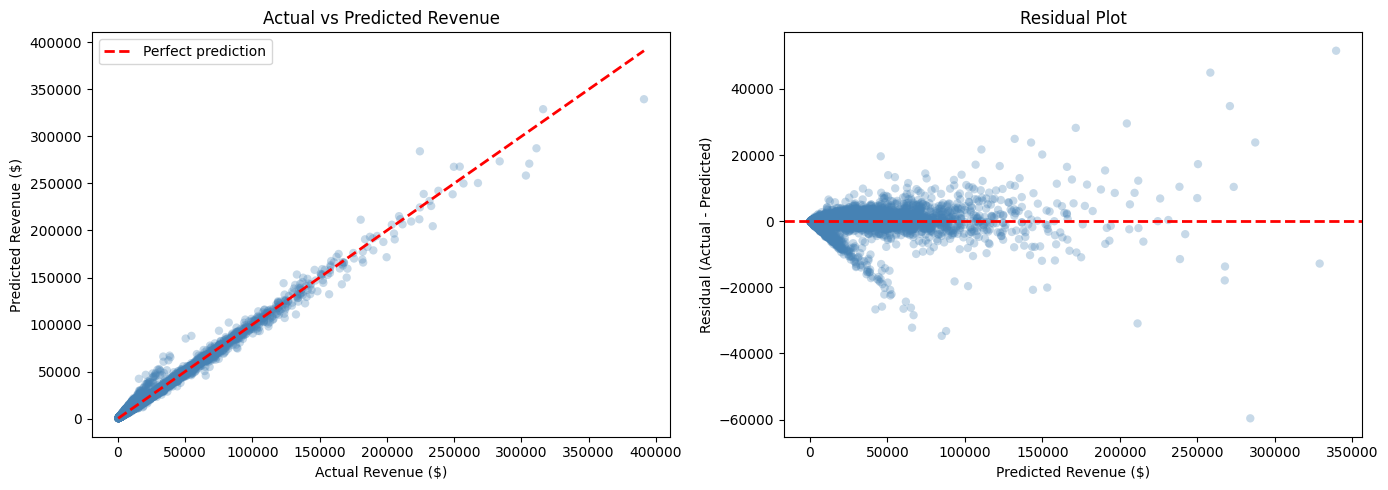

In [14]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = regressor.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='none')
# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Revenue ($)')
axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].set_title('Actual vs Predicted Revenue')
axes[0].legend()

# --- Plot 2: Residuals ---
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='steelblue', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Revenue ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()